# Spatial Lapse Rate from Juneau Icefield Temperature Data

### Prep to import Juneau Icefield temperature data at daily resolution

In [ ]:
import glob

root_folder = '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/'

# Get only daily files (i.e. no hourly files)
file_list = glob.glob(root_folder+'*_daily*.csv')

print(file_list)
print(len(file_list))

['/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefieldCamp18AWS_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1196_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1293_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield2050_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1705_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefieldCamp17AWS_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield2121_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1285_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1618_daily_LVL2.csv', '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/LVL2/juneauicefield1445_daily_LVL2.csv', '/Users/j

In [ ]:
import pandas as pd
pd.get_option("display.max_columns")

def load_dataframe(file_path, index_col):
    
    df = pd.read_csv(file_path, header=0, index_col=index_col)
    
    df.index = pd.DatetimeIndex(df.index)
    
    return df

### Check out one of the files using a pandas dataframe

In [ ]:
file_path = file_list[0]

df = load_dataframe(file_path, 'Date')

df.head(10)

,site_temp_min,site_temp_max,site_temp_WMO,site_temp_USGS,Barom,RelHum,WindGustSpeed,WindSpeed,VecAvgWindDir
Date,,,,,,,,,
2012-07-10,-2.1,1.3,-0.4,-1.1,5.9,98.0,NaN,NaN,NaN
2012-07-11,-2.6,1.9,-0.4,-0.8,5.9,97.4,NaN,3.3,NaN
2012-07-12,-1.2,6.1,2.4,3.9,5.9,65.5,NaN,2.5,83.0
2012-07-13,3.5,5.0,4.3,4.3,5.9,95.2,NaN,2.7,132.0
2012-07-14,2.4,8.3,5.3,4.6,5.9,90.1,NaN,0.9,221.0
2012-07-15,4.6,8.3,6.5,7.0,6.0,66.6,NaN,1.7,158.0
2012-07-16,0.7,5.1,2.9,2.1,6.0,99.4,NaN,2.5,NaN
2012-07-17,0.4,7.5,4.0,4.6,6.0,86.1,NaN,1.1,252.0
2012-07-18,3.2,9.4,6.3,6.4,6.0,73.3,NaN,1.5,NaN


In [ ]:
# Prep the data to average to annual resolution

df['year'] = df.index.year
df['month'] = df.index.month

df.head(10)

,site_temp_min,site_temp_max,site_temp_WMO,site_temp_USGS,Barom,RelHum,WindGustSpeed,WindSpeed,VecAvgWindDir,year,month
Date,,,,,,,,,,,
2012-07-10,-2.1,1.3,-0.4,-1.1,5.9,98.0,NaN,NaN,NaN,2012,7
2012-07-11,-2.6,1.9,-0.4,-0.8,5.9,97.4,NaN,3.3,NaN,2012,7
2012-07-12,-1.2,6.1,2.4,3.9,5.9,65.5,NaN,2.5,83.0,2012,7
2012-07-13,3.5,5.0,4.3,4.3,5.9,95.2,NaN,2.7,132.0,2012,7
2012-07-14,2.4,8.3,5.3,4.6,5.9,90.1,NaN,0.9,221.0,2012,7
2012-07-15,4.6,8.3,6.5,7.0,6.0,66.6,NaN,1.7,158.0,2012,7
2012-07-16,0.7,5.1,2.9,2.1,6.0,99.4,NaN,2.5,NaN,2012,7
2012-07-17,0.4,7.5,4.0,4.6,6.0,86.1,NaN,1.1,252.0,2012,7
2012-07-18,3.2,9.4,6.3,6.4,6.0,73.3,NaN,1.5,NaN,2012,7


In [ ]:
# Average the dataframe to annual resolution

df.groupby('year').mean()

,site_temp_min,site_temp_max,site_temp_WMO,site_temp_USGS,month
year,,,,,
1998,-4.805298,-1.525828,-3.162252,-3.202649,6.541209
1999,-3.944186,-1.609012,-2.771221,-2.774128,6.526027
2000,-3.927097,-1.254839,-2.592258,-2.683871,6.513661
2001,-4.692938,-2.030508,-3.359605,-3.457345,6.526027
2002,-4.923836,-1.613425,-3.265479,-3.318082,6.526027
2003,-4.545580,-1.543923,-3.044475,-3.096961,6.526027
2004,-3.567486,-0.542350,-2.052732,-2.150546,6.513661
2005,-3.530833,-0.604444,-2.069167,-2.118889,6.526027
2006,-5.610959,-2.692055,-4.151781,-4.205753,6.526027


### Plot the annually-averaged mean (USGS) temperature data for each station on the icefield

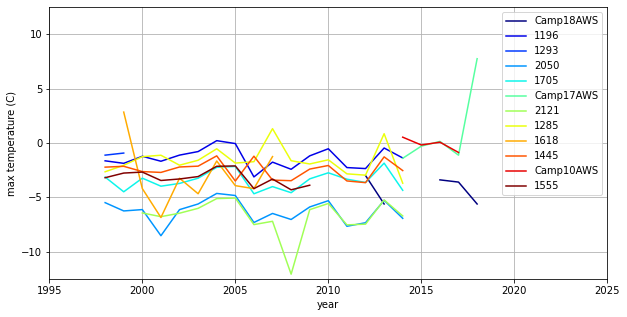

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

colors = plt.cm.jet(np.linspace(0,1,len(file_list)))

plt.figure(figsize=(10,5))

# load each station file, average to annual resolution, grab the elevation, and plot
for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df_yr = df.groupby('year').mean()
    
    label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
    plt.plot(df_yr.index.values, df_yr['site_temp_USGS'],
             '-', color=colors[ii], label=label)

plt.grid()
plt.legend()
plt.xlabel('year')
plt.ylabel('max temperature (C)')
plt.ylim([-12.5,12.5])
plt.xlim([1995,2025])
plt.show()

Is there a relationship between elevation and temperature? (The elevation is the label with units of meters.)

### Plot daily maximum temperatures for each station for the year 2002

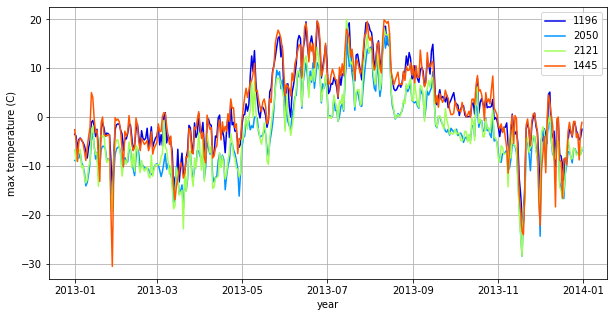

In [ ]:
plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[df['year']==2013]
    
    df_2002_nona = df_2002['site_temp_max'].dropna()
    
    if len(df_2002_nona) == 365: 
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]

        plt.plot(df_2002_nona.index.values, df_2002_nona.values,
                     '-', color=colors[ii], label=label)

plt.grid()
plt.legend()
plt.xlabel('year')
plt.ylabel('max temperature (C)')
#plt.ylim([-12.5,12.5])
#plt.xlim([2001,2003])
plt.show()  

# Calculate Lapse Rate for Each Day Individually

In [ ]:
##Jonny + Xander Code start

from scipy import stats

All_Data = np.zeros([len(file_list),2018-1998+1,365]) * np.nan

# Get all data into single array
for iYear, Year in enumerate(range(1998,2019)):
    for ii, file_path in enumerate(file_list):
        df = load_dataframe(file_path, 'Date')
        df['year'] = df.index.year
        df['month'] = df.index.month

        df_AllYears = df[(df['year']==Year)]

        df_All = df_AllYears['site_temp_USGS']
    
        if len(df_All) == 365:
            All_Data[ii,iYear,:] = df_All

# Get station elevations
# elvs = []
# print(len(file_list))
# for ii, file_path in enumerate(file_list):
#     label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
#     elvs += [int(label)]
# print(elvs) # THIS ISN'T WORKING, MAY NEED TO HARD CODE ELEVATIONS

elvs = np.array([1700,1196,1293,2050,1705,1302,2121,1285,1618,1445,1069,1555])
print(elvs)       

[1700 1196 1293 2050 1705 1302 2121 1285 1618 1445 1069 1555]


In [ ]:
slope_list = np.zeros([21,365]) * np.nan
intercept_list = np.zeros([21,365]) * np.nan
    
# Get lapse rate for each day over time period of interest
# (only calculates if > 4 data points for the given day)
for year in range(0,21):
    for day in range(365):
        temps = []
        Ts_wNan = All_Data[:,year,day]
        iNotNan = np.where(np.isnan(Ts_wNan)==False)
        
#         print(iNotNan)
        
        if len(iNotNan[0]) > 3:
            Ts_noNan = Ts_wNan[iNotNan]
            Elv_noNan = elvs[iNotNan]
        
            significance_threshold = 0.05

            r, p_value = stats.pearsonr(Elv_noNan,Ts_noNan)
#             print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

            slope, intercept, r_value, p_value, slope_stderr = stats.linregress(Elv_noNan, Ts_noNan)

#             print('Slope = ', slope)
#             print('Intercept = ', intercept)
        
            slope_list[year,day] = slope
            intercept_list[year,day] = intercept
#         for i in All_Data[:,year,day]:
#             print(i)

print("Done")

Done


In [ ]:
print(slope_list[12])

[-0.00257688  0.00250962 -0.00346864 -0.00166594  0.00784539 -0.00042334
 -0.00096086 -0.00528137 -0.00505442 -0.0014519   0.0079141   0.00111941
 -0.00393397 -0.00606392 -0.0061502  -0.0060124  -0.00569542 -0.00606201
 -0.00629449 -0.00387014 -0.00381565 -0.00621302 -0.00677965 -0.00696139
 -0.00610891  0.00252004 -0.00530835 -0.00185889 -0.00397834  0.00022368
 -0.00339196 -0.00577503 -0.00512212 -0.00576522 -0.00598729 -0.00319993
 -0.00479961 -0.00595838 -0.00649428 -0.00620316 -0.00438329 -0.00343708
 -0.00201622 -0.00466185 -0.00635627 -0.00694104 -0.00575393 -0.00533917
 -0.00339881 -0.00334863 -0.00376757 -0.00346864 -0.00444681 -0.0067807
 -0.0050933  -0.00635635 -0.00598929 -0.00560854 -0.00548199 -0.00546237
 -0.00653308 -0.0067439  -0.00653025 -0.00693655 -0.00650797 -0.00748138
 -0.00674674 -0.00624179 -0.00728591 -0.00715129 -0.00696445 -0.00625901
 -0.00502068 -0.0063771  -0.00742048 -0.00676282 -0.00534746 -0.00584822
 -0.00618738 -0.00627819 -0.0051008  -0.00378849 -0.

# Plot Lapse Rates (averaged over years) over Time

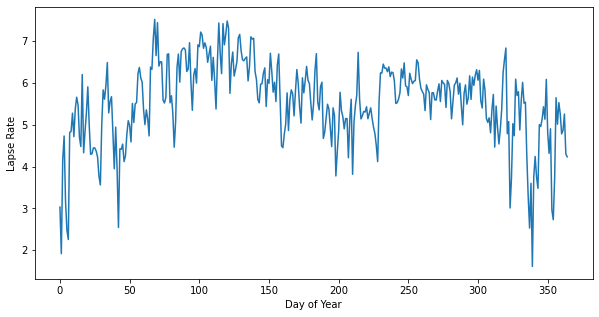

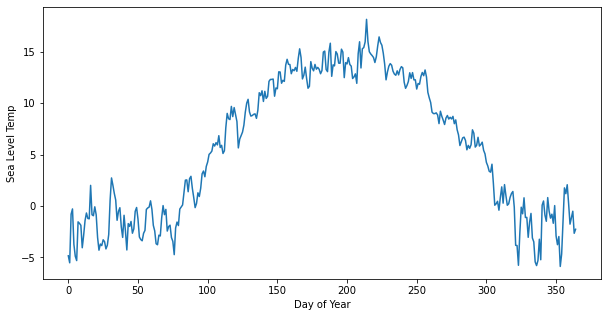

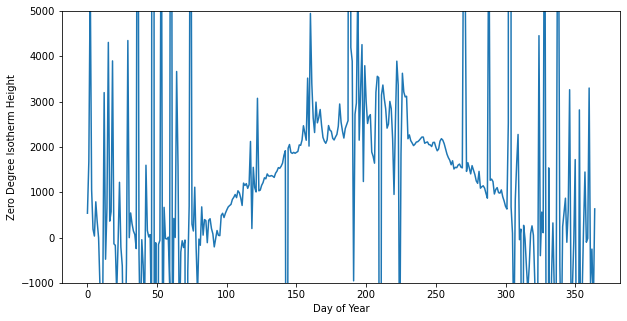

In [ ]:
import matplotlib.pyplot as plt

Slope_Mean = np.nanmean(slope_list,0)
Intercept_Mean = np.nanmean(intercept_list,0)
Seasonal_Isotherm_Height = np.nanmean(-intercept_list/slope_list,0)

plt.figure(figsize=(10,5))
plt.plot(Slope_Mean*-1000)
plt.xlabel('Day of Year')
plt.ylabel('Lapse Rate')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(Intercept_Mean)
plt.xlabel('Day of Year')
plt.ylabel('Sea Level Temp')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(Seasonal_Isotherm_Height)
plt.xlabel('Day of Year')
plt.ylabel('Zero Degree Isotherm Height')
plt.ylim([-1000,5000])
plt.show()

Text(0, 0.5, 'Smoothed Isotherm Height')

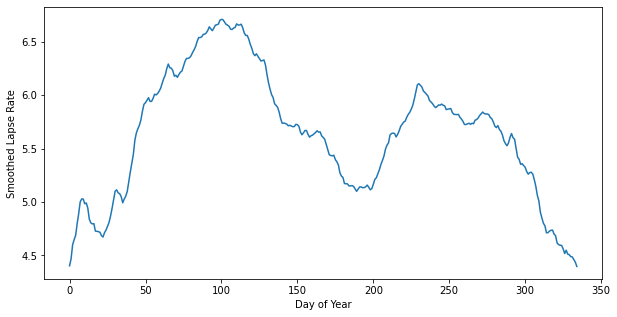

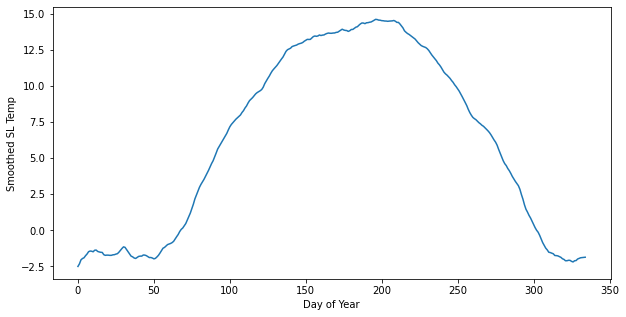

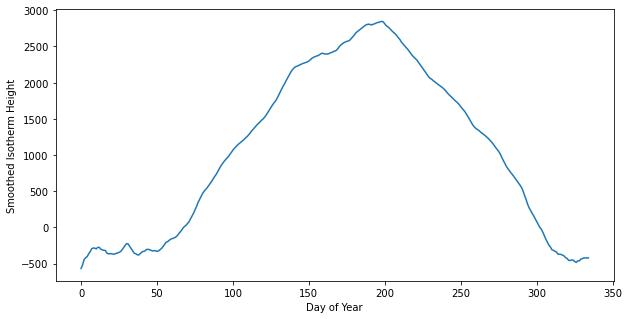

In [ ]:
#Smoothing Data before plotting

Smooth_Int = 30
Smoothed_Slope = np.zeros([365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Slope[i] = np.mean(Slope_Mean[i:i+Smooth_Int])

plt.figure(figsize=(10,5))
plt.plot(Smoothed_Slope*-1000)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Lapse Rate')
# plt.ylim([-1000,5000])

Smooth_Int = 30
Smoothed_Intercept = np.zeros([365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Intercept[i] = np.mean(Intercept_Mean[i:i+Smooth_Int])

plt.figure(figsize=(10,5))
plt.plot(Smoothed_Intercept)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed SL Temp')

Smooth_Int = 30
Smoothed_Iso = np.zeros([365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Iso[i] = np.mean(Seasonal_Isotherm_Height[i:i+Smooth_Int])

plt.figure(figsize=(10,5))
plt.plot(-Smoothed_Intercept / Smoothed_Slope)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Isotherm Height')

In [ ]:
IsoTherm = -Smoothed_Intercept / Smoothed_Slope

# root_folder = '/Volumes/NO NAME/JIF DEM'
# file_name = 'ASTGTM_N58W135_dem.tif'

# (root_folder + file_name)

for i in range(365):
    print(IsoTherm[i])
    

-567.5930627486924
-518.7854917747492
-444.1954876518363
-419.38539081751185
-405.02077612301883
-365.74692786581846
-334.9071458182032
-295.5986846266286
-284.8043963848765
-287.0549231180029
-297.5026208656147
-275.9387126468893
-275.92078902079885
-301.46040125174295
-310.83158647786536
-316.82261021301264
-318.4744420004603
-355.98589239720144
-365.8582543191746
-363.02520683626847
-363.987659187214
-369.35717387908454
-370.19280743805786
-359.6765128067793
-355.5638621409134
-344.61688715280064
-335.70777236934686
-309.99839852974725
-278.61838273293745
-249.601967178646
-224.2321719897769
-229.67283465920406
-261.1683373705895
-290.7400411092574
-324.6059185075422
-357.50928082958075
-364.50335400955726
-378.4674732808881
-381.3905391810724
-361.52670895879817
-341.3893268640418
-332.5388962326914
-327.4173213376713
-306.0621445887447
-303.22894458542413
-307.4809186682501
-317.0028063673463
-326.23370171142403
-321.2006529080861
-323.5772479677229
-332.676328252383
-325.86272576

# Plot Average Lapse Rates over Years

/var/folders/ls/6m85q_sx5z77b_1cj90dj4dc0000gn/T/ipykernel_69497/710415833.py:3: RuntimeWarning: Mean of empty slice
  Slope_Mean = np.nanmean(slope_list,1)
/var/folders/ls/6m85q_sx5z77b_1cj90dj4dc0000gn/T/ipykernel_69497/710415833.py:4: RuntimeWarning: Mean of empty slice
  Intercept_Mean = np.nanmean(intercept_list,1)
/var/folders/ls/6m85q_sx5z77b_1cj90dj4dc0000gn/T/ipykernel_69497/710415833.py:5: RuntimeWarning: Mean of empty slice
  Seasonal_Isotherm_Height = np.nanmean(-intercept_list/slope_list,1)


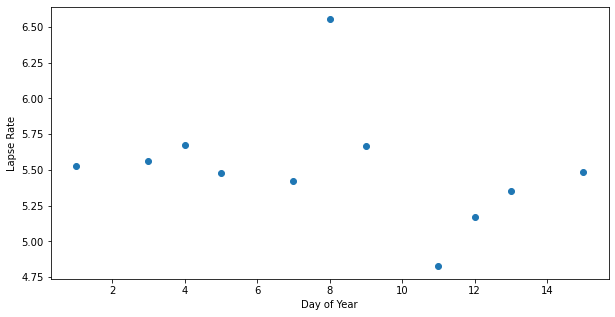

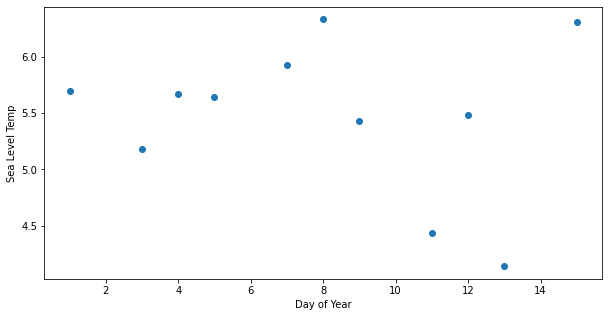

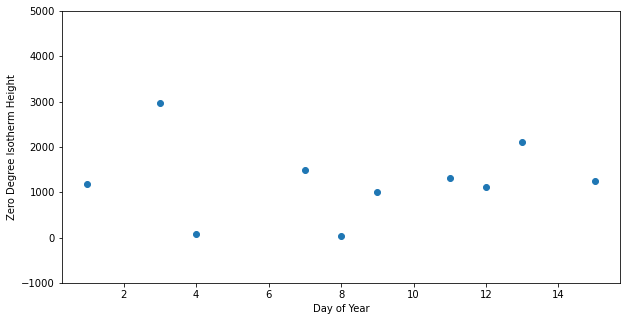

In [ ]:
import matplotlib.pyplot as plt

Slope_Mean = np.nanmean(slope_list,1)
Intercept_Mean = np.nanmean(intercept_list,1)
Seasonal_Isotherm_Height = np.nanmean(-intercept_list/slope_list,1)

plt.figure(figsize=(10,5))
plt.plot(Slope_Mean*-1000, 'o')
plt.xlabel('Day of Year')
plt.ylabel('Lapse Rate')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(Intercept_Mean, 'o')
plt.xlabel('Day of Year')
plt.ylabel('Sea Level Temp')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(Seasonal_Isotherm_Height, 'o')
plt.xlabel('Day of Year')
plt.ylabel('Zero Degree Isotherm Height')
plt.ylim([-1000,5000])
plt.show()

# July lapse rate over time

/var/folders/ls/6m85q_sx5z77b_1cj90dj4dc0000gn/T/ipykernel_69497/1426068534.py:1: RuntimeWarning: Mean of empty slice
  Slope_Mean = np.nanmean(slope_list[:, 181:212],1)
/var/folders/ls/6m85q_sx5z77b_1cj90dj4dc0000gn/T/ipykernel_69497/1426068534.py:2: RuntimeWarning: Mean of empty slice
  Intercept_Mean = np.nanmean(intercept_list[:, 181:212],1)
/var/folders/ls/6m85q_sx5z77b_1cj90dj4dc0000gn/T/ipykernel_69497/1426068534.py:3: RuntimeWarning: Mean of empty slice
  Seasonal_Isotherm_Height = np.nanmean(-intercept_list[:, 181:212]/slope_list[:, 181:212],1)


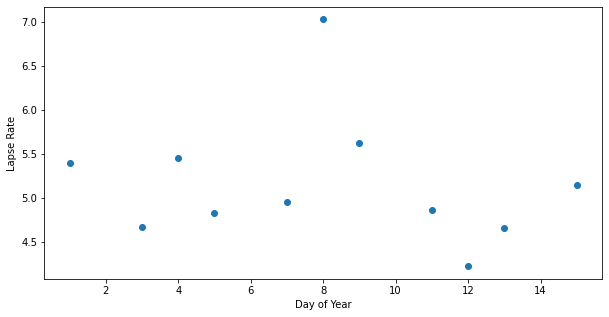

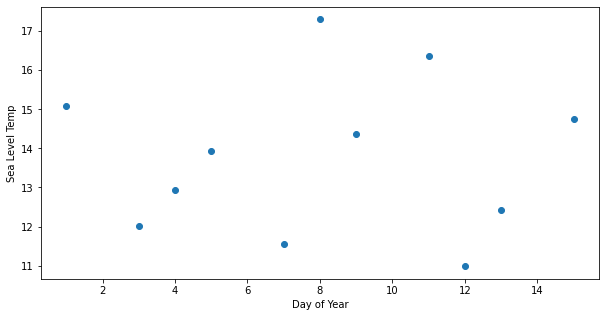

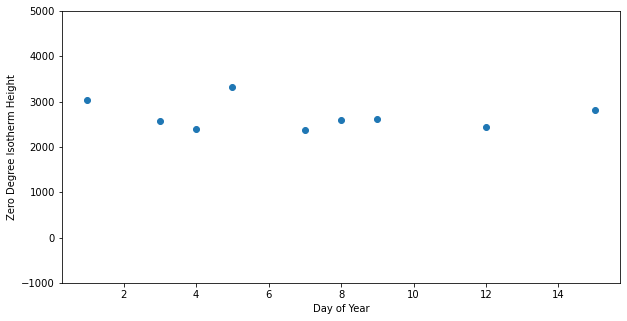

In [ ]:
Slope_Mean = np.nanmean(slope_list[:, 181:212],1)
Intercept_Mean = np.nanmean(intercept_list[:, 181:212],1)
Seasonal_Isotherm_Height = np.nanmean(-intercept_list[:, 181:212]/slope_list[:, 181:212],1)

plt.figure(figsize=(10,5))
plt.plot(Slope_Mean*-1000, 'o')
plt.xlabel('Day of Year')
plt.ylabel('Lapse Rate')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(Intercept_Mean, 'o')
plt.xlabel('Day of Year')
plt.ylabel('Sea Level Temp')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(Seasonal_Isotherm_Height, 'o')
plt.xlabel('Day of Year')
plt.ylabel('Zero Degree Isotherm Height')
plt.ylim([-1000,5000])
plt.show()

# Average Lapse Rate over Entire Time Period

In [ ]:
yearly_lapse = np.nanmean(Slope_Mean)
print(yearly_lapse)

july_lapse = np.nanmean(slope_list[:,181:212]) # July spans days 181-211 of the year!
print(july_lapse)

-0.005519847092524533
-0.005184289881878269


Done
Done


Text(0, 0.5, 'Warming')

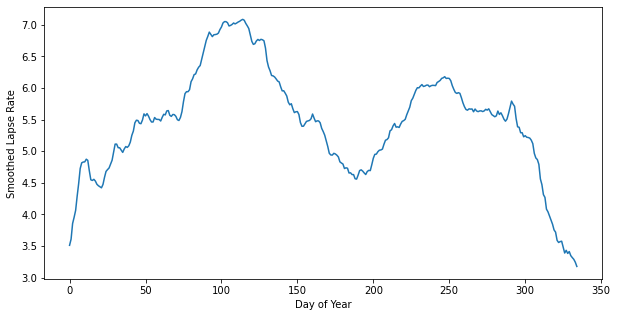

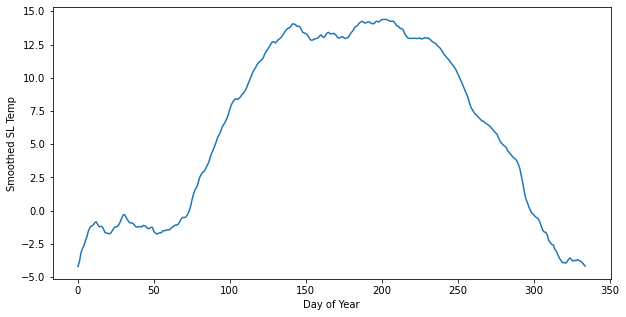

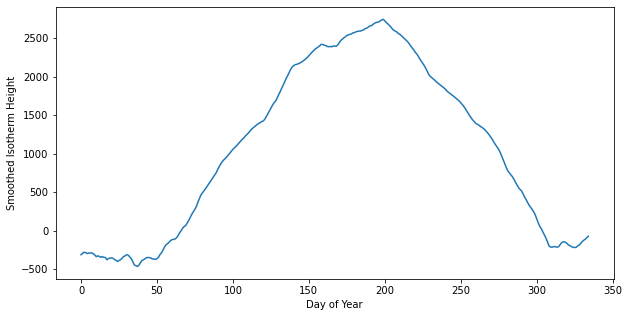

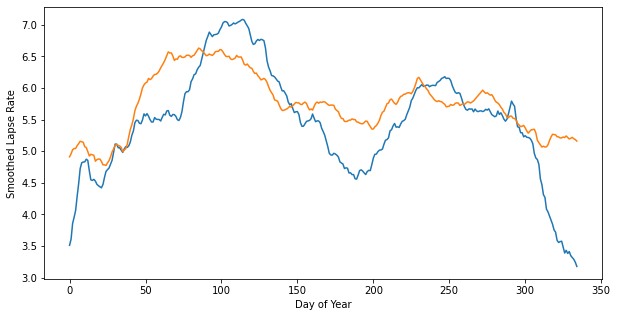

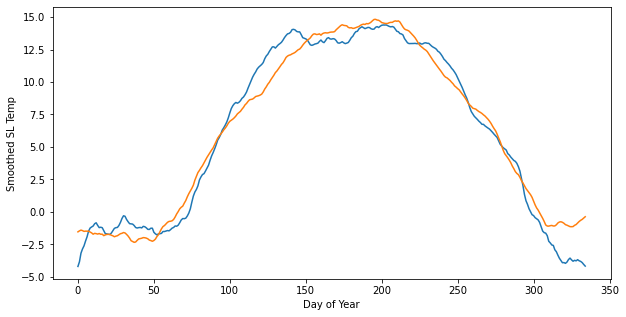

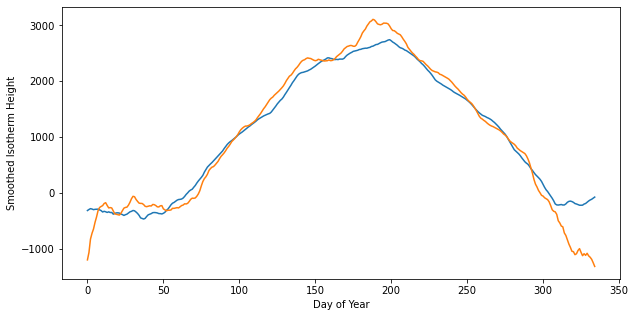

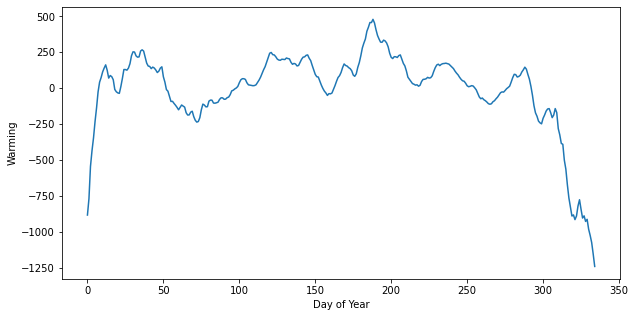

In [ ]:
slope_list = np.zeros([21,365]) * np.nan
intercept_list = np.zeros([21,365]) * np.nan
    
# Get lapse rate for each day over time period of interest
# (only calculates if >= 4 data points for the given day)

# first 10 years
for year in range(0,10):
    for day in range(365):
        temps = []
        Ts_wNan = All_Data[:,year,day]
        iNotNan = np.where(np.isnan(Ts_wNan)==False)
        
#         print(iNotNan)
        
        if len(iNotNan[0]) > 3:
            Ts_noNan = Ts_wNan[iNotNan]
            Elv_noNan = elvs[iNotNan]
        
            significance_threshold = 0.05

            r, p_value = stats.pearsonr(Elv_noNan,Ts_noNan)
#             print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

            slope, intercept, r_value, p_value, slope_stderr = stats.linregress(Elv_noNan, Ts_noNan)

#             print('Slope = ', slope)
#             print('Intercept = ', intercept)
        
            slope_list[year,day] = slope
            intercept_list[year,day] = intercept
#         for i in All_Data[:,year,day]:
#             print(i)

print("Done")

import matplotlib.pyplot as plt

Slope_Mean = np.nanmean(slope_list,0)
Intercept_Mean = np.nanmean(intercept_list,0)
Seasonal_Isotherm_Height = np.nanmean(-intercept_list/slope_list,0)

# plt.figure(figsize=(10,5))
# plt.plot(Slope_Mean*-1000)
# plt.xlabel('Day of Year')
# plt.ylabel('Lapse Rate')
# plt.show()

# plt.figure(figsize=(10,5))
# plt.plot(Intercept_Mean)
# plt.xlabel('Day of Year')
# plt.ylabel('Sea Level Temp')
# plt.show()

# plt.figure(figsize=(10,5))
# plt.plot(Seasonal_Isotherm_Height)
# plt.xlabel('Day of Year')
# plt.ylabel('Zero Degree Isotherm Height')
# plt.ylim([-1000,5000])
# plt.show()

Smooth_Int = 30
Smoothed_Slope_1 = np.zeros([365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Slope_1[i] = np.mean(Slope_Mean[i:i+Smooth_Int])

plt.figure(figsize=(10,5))
plt.plot(Smoothed_Slope*-1000)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Lapse Rate')
# plt.ylim([-1000,5000])

Smooth_Int = 30
Smoothed_Intercept_1 = np.zeros([365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Intercept_1[i] = np.mean(Intercept_Mean[i:i+Smooth_Int])

plt.figure(figsize=(10,5))
plt.plot(Smoothed_Intercept)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed SL Temp')

Smooth_Int = 30
Smoothed_Iso = np.zeros([365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Iso[i] = np.mean(Seasonal_Isotherm_Height[i:i+Smooth_Int])

plt.figure(figsize=(10,5))
plt.plot(-Smoothed_Intercept_1 / Smoothed_Slope_1)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Isotherm Height')

## Second 10 years
intercept_list = np.zeros([21,365]) * np.nan
    
# Get lapse rate for each day over time period of interest
# (only calculates if > 4 data points for the given day)
for year in range(10,21):
    for day in range(365):
        temps = []
        Ts_wNan = All_Data[:,year,day]
        iNotNan = np.where(np.isnan(Ts_wNan)==False)
        
#         print(iNotNan)
        
        if len(iNotNan[0]) > 3:
            Ts_noNan = Ts_wNan[iNotNan]
            Elv_noNan = elvs[iNotNan]
        
            significance_threshold = 0.05

            r, p_value = stats.pearsonr(Elv_noNan,Ts_noNan)
#             print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

            slope, intercept, r_value, p_value, slope_stderr = stats.linregress(Elv_noNan, Ts_noNan)

#             print('Slope = ', slope)
#             print('Intercept = ', intercept)
        
            slope_list[year,day] = slope
            intercept_list[year,day] = intercept
#         for i in All_Data[:,year,day]:
#             print(i)

print("Done")

import matplotlib.pyplot as plt

Slope_Mean = np.nanmean(slope_list[10:],0)
Intercept_Mean = np.nanmean(intercept_list[10:],0)
Seasonal_Isotherm_Height = np.nanmean(-intercept_list/slope_list,0)

# plt.figure(figsize=(10,5))
# plt.plot(Slope_Mean*-1000)
# plt.xlabel('Day of Year')
# plt.ylabel('Lapse Rate')
# plt.show()

# plt.figure(figsize=(10,5))
# plt.plot(Intercept_Mean)
# plt.xlabel('Day of Year')
# plt.ylabel('Sea Level Temp')
# plt.show()

# plt.figure(figsize=(10,5))
# plt.plot(Seasonal_Isotherm_Height)
# plt.xlabel('Day of Year')
# plt.ylabel('Zero Degree Isotherm Height')
# plt.ylim([-1000,5000])
# plt.show()

Smooth_Int = 30
Smoothed_Slope = np.zeros([365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Slope[i] = np.mean(Slope_Mean[i:i+Smooth_Int])

plt.figure(figsize=(10,5))
plt.plot(Smoothed_Slope*-1000)
plt.plot(Smoothed_Slope_1*-1000)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Lapse Rate')
# plt.ylim([-1000,5000])

Smooth_Int = 30
Smoothed_Intercept = np.zeros([365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Intercept[i] = np.mean(Intercept_Mean[i:i+Smooth_Int])

plt.figure(figsize=(10,5))
plt.plot(Smoothed_Intercept)
plt.plot(Smoothed_Intercept_1)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed SL Temp')

Smooth_Int = 30
Smoothed_Iso = np.zeros([365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Iso[i] = np.mean(Seasonal_Isotherm_Height[i:i+Smooth_Int])

plt.figure(figsize=(10,5))
plt.plot(-Smoothed_Intercept_1 / Smoothed_Slope_1)
plt.plot(-Smoothed_Intercept / Smoothed_Slope)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Isotherm Height')

plt.figure(figsize=(10,5))
plt.plot((-Smoothed_Intercept / Smoothed_Slope) - (-Smoothed_Intercept_1 / Smoothed_Slope_1))
# plt.plot()
plt.xlabel('Day of Year')
plt.ylabel('Warming')

In [ ]:
slope_list.shape

(21, 365)

# Spaghetti Plot of Lapse Rate over year for all years

/var/folders/ls/6m85q_sx5z77b_1cj90dj4dc0000gn/T/ipykernel_69497/1215566350.py:5: RuntimeWarning: Mean of empty slice
  Smoothed_Slope[iYear,i] = np.nanmean(slope_list[iYear,i:i+Smooth_Int])


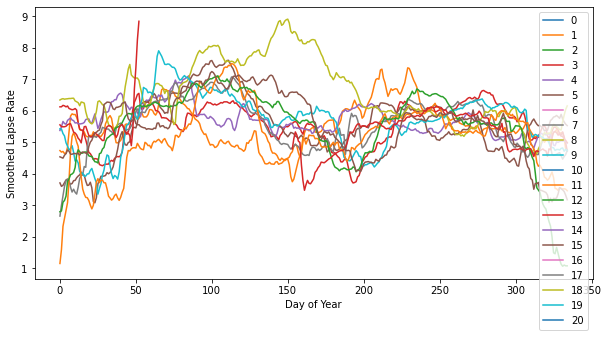

In [ ]:
Smooth_Int = 30
Smoothed_Slope = np.zeros([21,365]) * np.nan
for i in range(365-Smooth_Int):
    for iYear in range(21):
        Smoothed_Slope[iYear,i] = np.nanmean(slope_list[iYear,i:i+Smooth_Int])      

plt.figure(figsize=(10,5))
plt.plot(Smoothed_Slope.T*-1000)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Lapse Rate')
plt.legend(np.arange(0,21))
# plt.ylim([-1000,5000])


# First Decade Lapse Rates vs Second Decade Lapse Rates

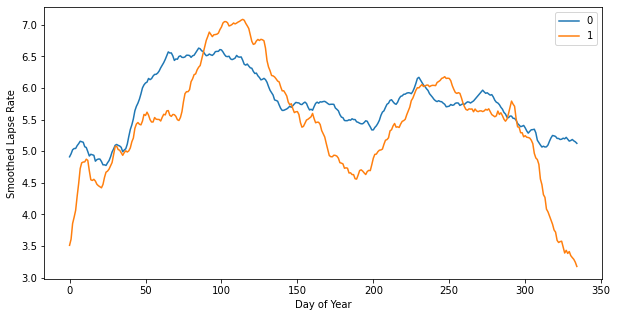

In [ ]:
Smooth_Int = 30
Smoothed_Slope = np.zeros([2,365]) * np.nan
for i in range(365-Smooth_Int):
    Smoothed_Slope[0,i] = np.nanmean(slope_list[:10,i:i+Smooth_Int])
    Smoothed_Slope[1,i] = np.nanmean(slope_list[10:,i:i+Smooth_Int])
    
plt.figure(figsize=(10,5))
plt.plot(Smoothed_Slope.T*-1000)
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Lapse Rate')
plt.legend(np.arange(0,21))
# plt.ylim([-1000,5000])


In [ ]:
Smoothed_Slope.shape

(21, 365)

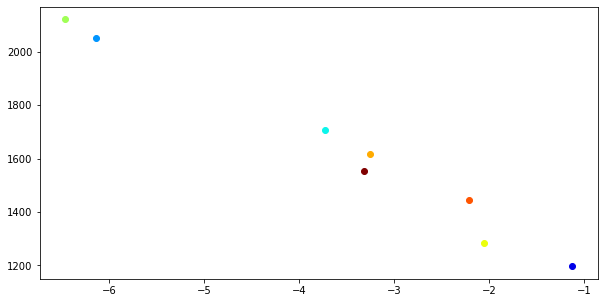

In [ ]:

elvs = []
Ts = []

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[(df['year']==2002)]
    
    df_2002_nona = df_2002['site_temp_USGS'].dropna()
    
    if len(df_2002_nona) == 365:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]

# plt.grid()
# plt.legend()
# plt.ylabel('elevation (m)')
# plt.xlabel('temperature (C)')
# #plt.ylim([-12.5,12.5])
# #plt.xlim([2001,2003])
# plt.show() 






### Plot elevation vs. annually-averaged USGS site temperature for the year 2002 and calculate the spatial lapse rate

In [ ]:
elvs = []
Ts = []

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[(df['year']==2002)]
    
    df_2002_nona = df_2002['site_temp_USGS'].dropna()
    
    if len(df_2002_nona) == 365:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
#plt.ylim([-12.5,12.5])
#plt.xlim([2001,2003])
plt.show() 

TypeError: 'int' object is not iterable

<Figure size 720x360 with 0 Axes>

In [ ]:
from scipy import stats

significance_threshold = 0.05

r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9901290269158615
P-value = 2.386707314786073e-06
Slope =  -0.005675132817404084
Intercept =  5.668294394391631


### Plot elevation vs. January USGS site temperature and calculate the spatial lapse rate

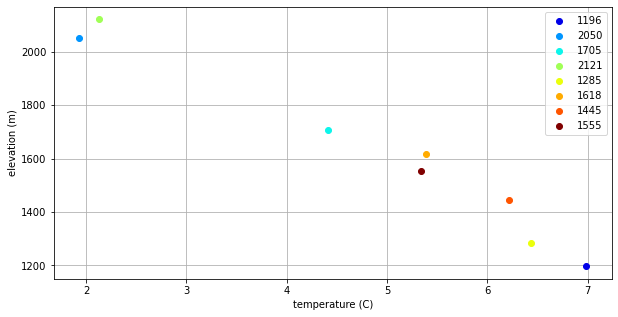

In [ ]:
elvs = []
Ts = []

month = 8
#year = 2002

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    # Choose this line of code to average over one year
    #df_2002 = df[(df['year']==year) & (df['month']==month)]
    
    # Choose the next two lines of code to average over all years
    foo = df[df['month']==month]
    df_2002 = foo.groupby('year').mean()
    
    df_2002_nona = df_2002['site_temp_USGS'].dropna()
    
    if len(df_2002_nona) > 5:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
    
        #plt.plot(df_2002_nona.values, np.tile(int(label),df_2002_nona.shape),
        #         'o', color=colors[ii], label=label)
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
#plt.ylim([-12.5,12.5])
#plt.xlim([2001,2003])
plt.show() 

In [ ]:
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9832907318496411
P-value = 1.151738184197737e-05
Slope =  -0.005670632563874948
Intercept =  14.052389560397284


Month = 1 Slope = -0.003823770408666815
Month = 2 Slope = -0.00517975208864898
Month = 3 Slope = -0.006453112417882392
Month = 4 Slope = -0.0067398492199972826
Month = 5 Slope = -0.006147510917763865
Month = 6 Slope = -0.005647068149780346
Month = 7 Slope = -0.005226297676336247
Month = 8 Slope = -0.005670632563874948
Month = 9 Slope = -0.005810153730495709
Month = 10 Slope = -0.005771959710727745
Month = 11 Slope = -0.0051242723421097815
Month = 12 Slope = -0.003808985257163036


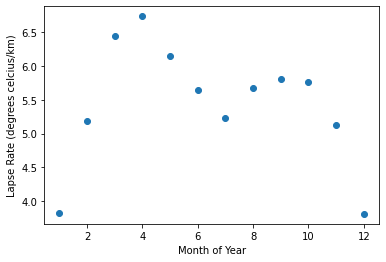

In [ ]:
lapses = []

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[df['year']==2005]
    
    df_2002_nona = df_2002['site_temp_max'].dropna()
    
    if len(df_2002_nona) > 300: 
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]

        plt.plot(df_2002_nona.index.values, df_2002_nona.values,
                     '-', color=colors[ii], label=label)

plt.grid()
plt.legend()
plt.xlabel('year')
plt.ylabel('max temperature (C)')
#plt.ylim([-12.5,12.5])
#plt.xlim([2001,2003])
plt.show()  

for month in range(1, 13):
    elvs = []
    Ts = []
    
    for ii, file_path in enumerate(file_list):  
        df = load_dataframe(file_path, 'Date')
        df['year'] = df.index.year
        df['month'] = df.index.month

        # Choose this line of code to average over one year
        #df_2002 = df[(df['year']==year) & (df['month']==month)]

        # Choose the next two lines of code to average over all years
        foo = df[df['month']==month]
        df_2002 = foo.groupby('year').mean()

        df_2002_nona = df_2002['site_temp_USGS'].dropna()

        if len(df_2002_nona) > 5:

            label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
            elvs = elvs + [int(label)]
            Ts = Ts + [df_2002_nona.values.mean()]
    
    r, p_value = stats.pearsonr(elvs,Ts)
    slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)
    
    lapses += [-slope*1000]

    print('Month = ' + str(month) + ' Slope = ' + str(slope))

plt.plot(range(1,13), lapses, 'o')
plt.xlabel('Month of Year')
plt.ylabel('Lapse Rate (degrees celcius/km)')
plt.show()

How do the lapse rates of the min and max temperatures differ?

How do the lapse rates differ by month?

How do the lapse rates differ by year?

Can you plot the best-fit line on the graph?

Why are the lapse rates noticeably lower in the winter months?

### Where are these stations?

In [ ]:
loc_file_path = '/Users/jabadgeley/JIRP/data/juneauIceField_weather_v1.0/WeatherStationLocations.csv'
df_locs = pd.read_csv(loc_file_path, header=0, index_col='Elevation')

df_locs.head(10)

,Location,Latitude,Longitude,NWIS ID
Elevation,,,,
1196,C-10,59.575640,-133.709820,NaN
1285,C-17,58.647210,-134.206350,NaN
1445,C-26,58.367370,-134.366380,NaN
1555,C-9,59.016640,-134.121040,NaN
1618,C-29,58.712433,-134.182217,NaN
1705,C-18,59.342110,-134.102210,NaN
2050,C-8,58.834970,-134.276430,NaN
2121,C-25,58.806700,-134.136130,NaN


Text(-133, 58.3019, 'Juneau')

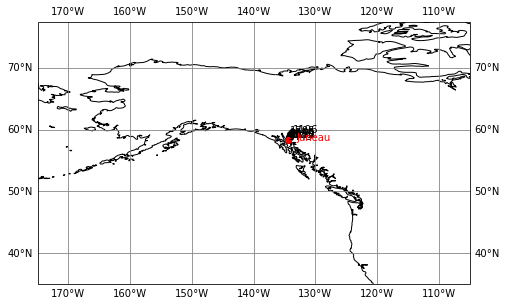

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cf 
from matplotlib.offsetbox import AnchoredText

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-175, -105, 35, 75], ccrs.Geodetic())

ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)
ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
#ax.add_feature(cf.STATES, edgecolor='k', linewidth=1) 

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)

ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-133, 58.3019, 'Juneau', color='r', transform=proj)

Text(-134.4197, 58.3019, '17')

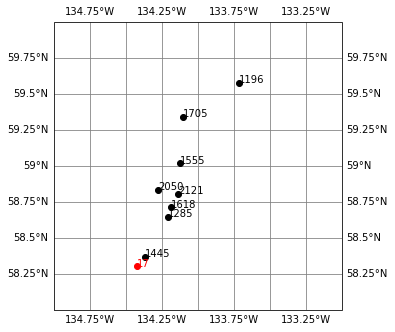

In [ ]:
proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-135, -133, 58, 60], ccrs.Geodetic())

#ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
#ax.add_feature(cf.STATES, edgecolor='k', linewidth=1)  
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)
    
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-134.4197, 58.3019, '17', color='r', transform=proj)

### The following compares the lapse rates to ERA5 data, which we can do if we have time. For now, let's skip this.

In [ ]:
file_path = '/Users/jabadgeley/JIRP/data/ERA5/'
file_name = 'z_Amon_ERA5_2002.nc'

import xarray as xr
ds_z_full = xr.open_dataset(file_path+file_name)
ds_z = ds_z_full.sel(longitude=slice(-175 % 360, -105 % 360), latitude=slice(75, 35), time='2002-01-01')

z_plot = np.squeeze(ds_z.z.values)

longitudes = ((ds_z['longitude'] + 180) % 360) - 180
meshlons, meshlats = np.meshgrid(longitudes, ds_z.latitude.values)

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-135, -133, 58, 60], ccrs.Geodetic())

ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
#ax.add_feature(cf.STATES, edgecolor='k', linewidth=1)  
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)

cs = ax.pcolormesh(meshlons, meshlats, z_plot/9.81, cmap='viridis', 
                   vmin=0, vmax=2000, transform=proj)

cb = plt.colorbar(cs, ax=ax, pad=.1)
cb.set_label('meters', rotation=270, labelpad=14)

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)
    
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-134.4197, 58.3019, '17', color='r', transform=proj)

/Users/jabadgeley/anaconda3/envs/py3_geospat_new/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1797: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = matplotlib.axes.Axes.pcolormesh(self, *args, **kwargs)


Text(-134.4197, 58.3019, '17')

/Users/jabadgeley/anaconda3/envs/py3_geospat_new/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [Errno 8] nodename nor servname provided, or not known>

<Figure size 432x288 with 2 Axes>

In [ ]:
file_path = '/Users/jabadgeley/JIRP/data/ERA5/'
file_name = 't2m_Amon_ERA5_1979-2020.nc'

import xarray as xr
ds_t_full = xr.open_dataset(file_path+file_name)
ds_t = ds_t_full.sel(longitude=slice(-175 % 360, -105 % 360), 
                     latitude=slice(75, 35))#, 
                     #time=slice('2002-01-01','2002-12-01')).mean('time')
                     #time = '2002-01-01')

Text(-134.4197, 58.3019, '17')

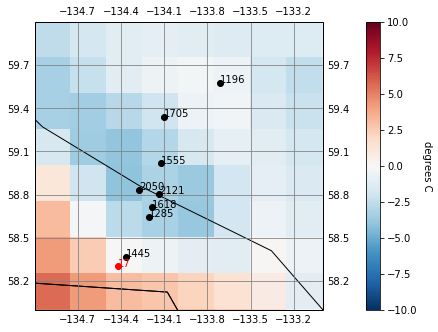

In [ ]:
longitudes = ((ds_t['longitude'] + 180) % 360) - 180
meshlons, meshlats = np.meshgrid(longitudes, ds_t.latitude.values)

t_plot = ds_t.t2m.mean('time').values

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-135, -133, 58, 60], ccrs.Geodetic())

ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
ax.add_feature(cf.STATES, edgecolor='k', linewidth=1)  
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)

cs = ax.pcolormesh(meshlons, meshlats, t_plot-273.15, cmap='RdBu_r', 
                   vmin=-10, vmax=10, transform=proj)

cb = plt.colorbar(cs, ax=ax, pad=.1)
cb.set_label('degrees C', rotation=270, labelpad=14)

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)
    
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-134.4197, 58.3019, '17', color='r', transform=proj)

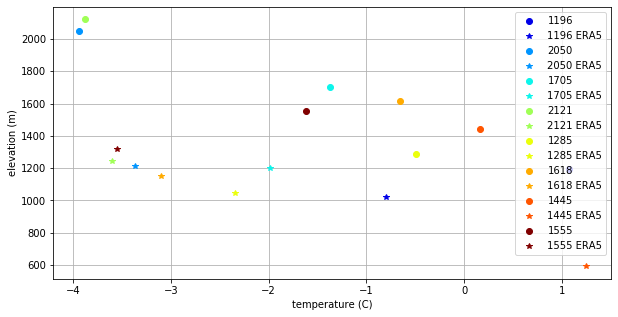

In [ ]:
elvs = []
Ts = []
elvs_ERA5 = []
Ts_ERA5 = []

dict_locs = df_locs.to_dict()

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[(df['year']==2002)]
    
    df_2002_nona = df_2002['site_temp_max'].dropna()
    
    if len(df_2002_nona) == 365:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
        
        lat = dict_locs['Latitude'][int(label)]
        lon = dict_locs['Longitude'][int(label)] % 360
        
        t_loc = ds_t.interp(latitude=lat, longitude=lon, method='linear').sel(time=slice('2002-01-01','2002-12-01')).mean('time')
        z_loc = ds_z.interp(latitude=lat, longitude=lon, method='linear')
        
        plt.plot(t_loc.t2m.values.mean()-273.15, z_loc.z.values.mean()/9.81, '*', color=colors[ii], label=label+' ERA5')
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]
        elvs_ERA5 = elvs_ERA5 + [z_loc.z.values.mean()/9.81]
        Ts_ERA5 = Ts_ERA5 + [t_loc.t2m.values.mean()-273.15]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
plt.show()     

In [ ]:
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))
slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)
print('Slope = ', slope)
print('Intercept = ', intercept, '\n')

r, p_value = stats.pearsonr(elvs_ERA5,Ts_ERA5)
print('ERA5 Correlation Coefficient = '+str(r)+'\nERA5 P-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs_ERA5, Ts_ERA5)

print('ERA5 Slope = ', slope)
print('ERA5 Intercept = ', intercept)

Correlation Coefficient = -0.9468971919225281
P-value = 0.00035961118399445685
Slope =  -0.005127540373240108
Intercept =  6.975613104492636 

ERA5 Correlation Coefficient = -0.934129966411392
ERA5 P-value = 0.0006796691515283236
ERA5 Slope =  -0.0069227439614270815
ERA5 Intercept =  5.4136943620663995


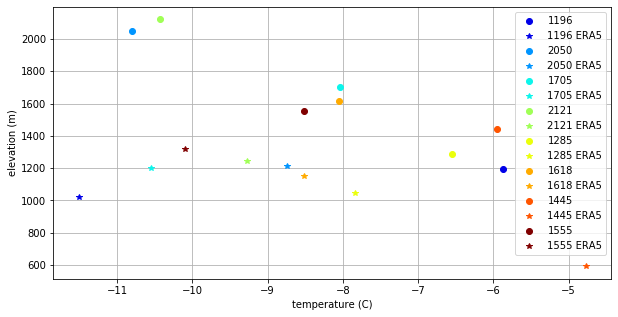

In [ ]:
elvs = []
Ts = []
elvs_ERA5 = []
Ts_ERA5 = []

dict_locs = df_locs.to_dict()

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[(df['year']==2002) & (df['month']==1)]
    
    df_2002_nona = df_2002['site_temp_max'].dropna()
    
    if len(df_2002_nona) > 0:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
        
        lat = dict_locs['Latitude'][int(label)]
        lon = dict_locs['Longitude'][int(label)] % 360
        
        t_loc = ds_t.interp(latitude=lat, longitude=lon, method='linear').sel(time='2002-01-01')
        z_loc = ds_z.interp(latitude=lat, longitude=lon, method='linear')
        
        plt.plot(t_loc.t2m.values.mean()-273.15, z_loc.z.values.mean()/9.81, '*', color=colors[ii], label=label+' ERA5')
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]
        elvs_ERA5 = elvs_ERA5 + [z_loc.z.values.mean()/9.81]
        Ts_ERA5 = Ts_ERA5 + [t_loc.t2m.values.mean()-273.15]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
plt.show()     

In [ ]:
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))
slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)
print('Slope = ', slope)
print('Intercept = ', intercept, '\n')

r, p_value = stats.pearsonr(elvs_ERA5,Ts_ERA5)
print('ERA5 Correlation Coefficient = '+str(r)+'\nERA5 P-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs_ERA5, Ts_ERA5)

print('ERA5 Slope = ', slope)
print('ERA5 Intercept = ', intercept)

Correlation Coefficient = -0.9459185485572129
P-value = 0.0003795778803346242
Slope =  -0.005375467234423798
Intercept =  0.6876907595407751 

ERA5 Correlation Coefficient = -0.7372418064206353
ERA5 P-value = 0.03688527117407227
ERA5 Slope =  -0.00665477059672018
ERA5 Intercept =  -1.603720856223105


### Now look at our own data!